*  DSC530-T303 Data Exploration and Analysis (2257-1)
*  Final Project
*  Charles Sarratt

# Final Project - Exploring Daily Weather Trends and Temperature Extremes in U.S. Cities

Dataset Source: Kaggle – Weather Dataset (US) (https://www.kaggle.com/datasets/nachiketkamod/weather-dataset-us)

## Why I Chose This Topic

Weather has always fascinated me, and this dataset offers the opportunity to dive into real-world climate data across multiple U.S. weather stations and years. I plan to explore seasonal trends, detect temperature anomalies, and analyze precipitation variability. These insights are not only personally interesting but also relevant to ongoing conversations about climate change and extreme weather.

## Dataset Suitability

The dataset includes tens of thousands of daily weather records sampled from a much larger file containing over 155 million entries. It includes variables such as observation date, maximum and minimum temperatures (`TMAX`, `TMIN`), daily precipitation (`PRCP`), and station-level geographic data (`Latitude`, `Longitude`, and `Elevation`). These variables are all numeric, making the dataset ideal for exploratory data analysis. The structure supports statistical summaries, correlation analysis, and modeling efforts such as regression or classification. 

## Preliminary Preparation Tasks

### 1. Dataset Selection

#### a. Adequacy Check

The dataset selected for this project is the **Weather Dataset (US)**, sourced from Kaggle. The original dataset includes over 155 million rows of daily weather data collected from weather stations across the United States. For manageability and performance, only the first 50,000 rows are used for this analysis.

This sample includes the following key variables:

- `DATE`: The observation date  
- `TMAX`: Maximum daily temperature (°F)  
- `TMIN`: Minimum daily temperature (°F)  
- `PRCP`: Daily precipitation (inches)  
- `Latitude` and `Longitude`: Geographical location of the weather station  
- `Elevation`: Elevation of the station in meters  
- `ID`: Weather station identifier  

These variables are sufficient for conducting univariate, bivariate, and multivariate analysis. The dataset supports questions related to climate trends, temperature variability, seasonal effects, and relationships between temperature, elevation, and geography. It is well-suited for regression, classification, and visualization tasks.

The code block below demonstrates the dataset structure and confirms the sample size and variable availability.

#### b. Data Integrity

The dataset is derived from NOAA's **Global Historical Climatology Network (GHCN)** and was uploaded to Kaggle by a third-party contributor in a cleaned CSV format. GHCN is a reliable, peer-reviewed source of global weather data.

Key data integrity considerations:

- **Missing Data:** The dataset contains missing values in core weather variables such as `TMAX`, `TMIN`, and `PRCP`. These will be addressed during the cleaning phase.
- **Measurement Biases:** Weather stations across the U.S. may vary in instrumentation, calibration, and reporting frequency. These differences could influence observed values.
- **Column Interpretation:**  
  - `ID` represents the NOAA weather station code, not a city name.  
  - `Latitude` and `Longitude` enable grouping or geospatial analysis by region.  
  - `Elevation` may impact temperature and will be analyzed in this context.  

Despite these limitations, the dataset is well-structured and appropriate for comprehensive exploratory analysis.

In [4]:
# Load and validate a sample of the full dataset
import pandas as pd

# Load a manageable sample (first 50,000 rows)
weather_df = pd.read_csv("data/Weather Data (US).csv", nrows=50000)

# Convert DATE column to datetime
weather_df['DATE'] = pd.to_datetime(weather_df['DATE'], errors='coerce')

# Confirm structure and sample preview
weather_df.info()
weather_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ID         50000 non-null  object        
 1   DATE       50000 non-null  datetime64[ns]
 2   TMAX       23727 non-null  float64       
 3   TMIN       23702 non-null  float64       
 4   EVAP       5 non-null      float64       
 5   PRCP       38476 non-null  float64       
 6   Latitude   50000 non-null  float64       
 7   Longitude  50000 non-null  float64       
 8   Elevation  50000 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 3.4+ MB


,ID,DATE,TMAX,TMIN,EVAP,PRCP,Latitude,Longitude,Elevation
0,USS0012M13S,1997-03-26,NaN,NaN,NaN,0.0,37.6600,-112.7400,2920.0
1,US1OKCV0021,2007-04-18,NaN,NaN,NaN,241.0,35.1715,-97.4262,355.1
2,USC00355174,1999-10-07,NaN,NaN,NaN,NaN,42.0078,-121.3186,1410.3
3,US1MDHW0012,2015-10-14,NaN,NaN,NaN,0.0,39.3387,-76.9468,166.1
4,US1TXHRS014,2021-10-04,NaN,NaN,NaN,0.0,32.7061,-94.1683,53.6


### 2. Data Cleaning and Preparation

#### a. Handle Missing Values or Outliers

The dataset initially included several missing values in core weather-related variables. These were identified using the `.isna().sum()` function.

We chose to drop rows with missing values in key columns (`TMAX`, `TMIN`, `PRCP`) since these are essential for our analysis. While this reduces the sample size slightly, it ensures the remaining data is complete for temperature and precipitation-related insights.

In [5]:
# Check missing values
weather_df.isna().sum()

# Drop rows with missing TMAX, TMIN, or PRCP values
weather_df_clean = weather_df.dropna(subset=['TMAX', 'TMIN', 'PRCP'])

# Confirm removal
weather_df_clean.isna().sum()
weather_df_clean.shape

(15646, 9)

We also inspected the dataset for outliers using boxplots. Some extreme values for temperature and precipitation were identified but retained, as they likely represent real weather events such as heatwaves or storms.

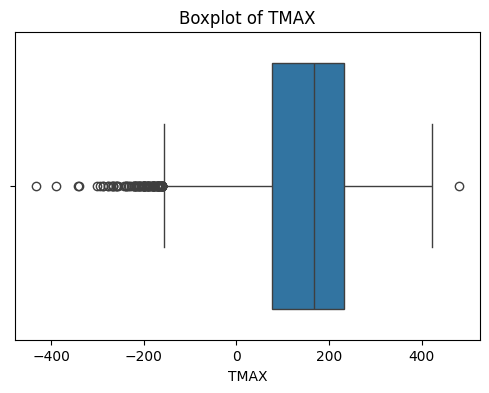

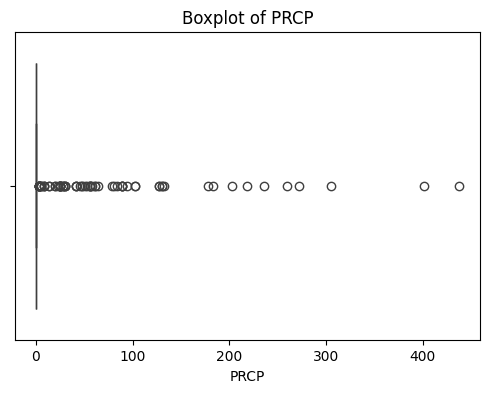

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for TMAX
plt.figure(figsize=(6, 4))
sns.boxplot(data=weather_df_clean, x='TMAX')
plt.title("Boxplot of TMAX")
plt.show()

# Boxplot for PRCP
plt.figure(figsize=(6, 4))
sns.boxplot(data=weather_df_clean, x='PRCP')
plt.title("Boxplot of PRCP")
plt.show()

Outliers were not removed at this stage because they may reflect meaningful climate extremes, which are valuable for analysis.

#### b. Recoding or Encoding of Variables

This dataset is composed entirely of numerical variables, so no categorical encoding (e.g., one-hot or label encoding) is necessary at this stage. However, we converted the `DATE` column to datetime format for potential time-based grouping or seasonal analysis.

In [7]:
# Convert DATE column to datetime
weather_df['DATE'] = pd.to_datetime(weather_df['DATE'])

#### c. Data Transformation (Handling Skewed Variables)

To assess skewness in the numerical variables, we used the `.skew()` function. Precipitation (`PRCP`) showed a strong positive skew, which is common due to many zero-rainfall days and occasional extreme weather events.

In [8]:
# Check skewness of numerical variables
weather_df_clean[['TMAX', 'TMIN', 'PRCP']].skew()

TMAX    -0.536894
TMIN    -0.793048
PRCP    33.957074
dtype: float64

We may apply log transformation to PRCP for modeling purposes later, but we retain the original values for exploratory analysis since the extremes are climatologically important.

#### d. Normalization or Standardization

Because we plan to run regression, classification, and clustering later in the project, we will normalize variables to a standard scale (mean = 0, standard deviation = 1). This is especially important when combining variables with different units or magnitudes, such as temperature (°F), precipitation (inches), and elevation (meters).

In [9]:
from sklearn.preprocessing import StandardScaler

# Select relevant columns for normalization
features_to_scale = ['TMAX', 'TMIN', 'PRCP', 'Elevation']

# Initialize scaler and apply
scaler = StandardScaler()
weather_scaled = scaler.fit_transform(weather_df_clean[features_to_scale])

# Convert back to DataFrame
weather_scaled_df = pd.DataFrame(weather_scaled, columns=features_to_scale)
weather_scaled_df.head()

,TMAX,TMIN,PRCP,Elevation
0,0.455018,1.009045,-0.044249,-0.658230
1,-1.076305,-0.213346,-0.044249,-0.927628
2,1.069381,1.438534,0.328367,-0.538524
3,1.069381,1.625747,3.433497,-0.744818
4,-0.003462,-0.026133,-0.044249,-0.908600


We will use this scaled DataFrame (`weather_scaled_df`) in future modeling steps like regression and clustering.

## Exploratory Data Analysis (EDA)

### 1. Describe the Variable Characteristics with Summary Statistics

This section provides an overview of the key variables used in this project. The summary statistics offer a snapshot of the central tendencies, spread, and shape of each distribution.

We focus on the following four numerical variables:

- **TMAX**: Maximum daily temperature (°F)
- **TMIN**: Minimum daily temperature (°F)
- **PRCP**: Daily precipitation (inches)
- **Elevation**: Elevation of the weather station (meters)

These variables were selected for their relevance to temperature trends, precipitation patterns, and geographic analysis.

In [10]:
# Summary statistics for key variables
weather_df_clean[['TMAX', 'TMIN', 'PRCP', 'Elevation']].describe()

,TMAX,TMIN,PRCP,Elevation
count,15646.000000,15646.000000,15646.000000,15646.000000
mean,150.377541,8.373003,0.356257,846.473303
std,109.059546,90.808546,8.051449,830.395123
min,-433.000000,-580.000000,0.000000,-999.900000
25%,76.000000,-44.000000,0.000000,205.400000
50%,167.000000,17.000000,0.000000,465.550000
75%,233.000000,78.000000,0.000000,1402.100000
max,480.000000,244.000000,437.000000,3535.700000


### 2. Conduct Univariate Analysis

#### a. Descriptive Statistics for Key Variables

We begin by calculating several descriptive statistics for the primary numerical variables in our dataset:

- **Mean**: Average value
- **Median**: Middle value
- **Mode**: Most frequent value
- **Variance**: Measure of spread
- **Skewness**: Measure of asymmetry
- **Kurtosis**: Measure of peakedness or tail heaviness

These metrics help us understand the central tendency, variability, and distribution shape for each variable.

In [11]:
from scipy.stats import skew, kurtosis, mode

# Select numeric columns
numeric_cols = ['TMAX', 'TMIN', 'PRCP', 'Elevation']

# Compute descriptive statistics manually
for col in numeric_cols:
    print(f"--- {col} ---")
    print(f"Mean: {weather_df_clean[col].mean():.2f}")
    print(f"Median: {weather_df_clean[col].median():.2f}")
    print(f"Mode: {mode(weather_df_clean[col], keepdims=False).mode}")
    print(f"Variance: {weather_df_clean[col].var():.2f}")
    print(f"Skewness: {skew(weather_df_clean[col]):.2f}")
    print(f"Kurtosis: {kurtosis(weather_df_clean[col]):.2f}")
    print()

--- TMAX ---
Mean: 150.38
Median: 167.00
Mode: 228.0
Variance: 11893.98
Skewness: -0.54
Kurtosis: 0.02

--- TMIN ---
Mean: 8.37
Median: 17.00
Mode: 0.0
Variance: 8246.19
Skewness: -0.79
Kurtosis: 0.84

--- PRCP ---
Mean: 0.36
Median: 0.00
Mode: 0.0
Variance: 64.83
Skewness: 33.95
Kurtosis: 1395.72

--- Elevation ---
Mean: 846.47
Median: 465.55
Mode: 6.1
Variance: 689556.06
Skewness: 1.06
Kurtosis: 0.09



#### b. Visualizing Distributions

We now visualize the distributions of the key numerical variables using histograms, boxplots, and kernel density plots. These help detect the presence of skewness, outliers, and multimodal distributions.

We also include a heatmap of missing data from the original dataset to assess any patterns in missingness.

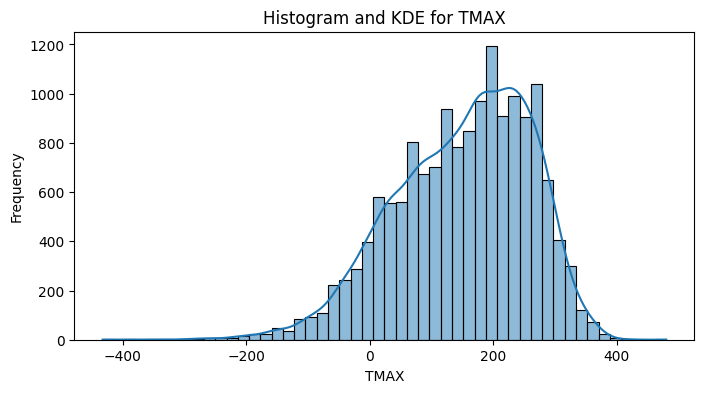

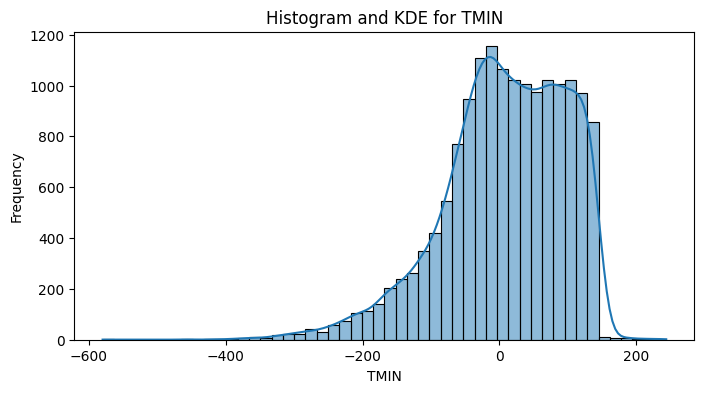

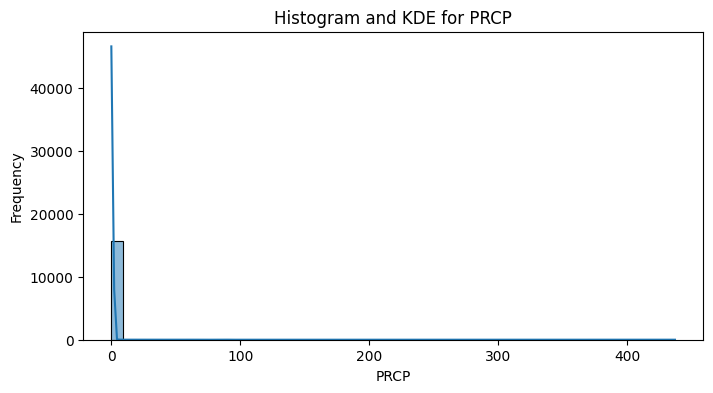

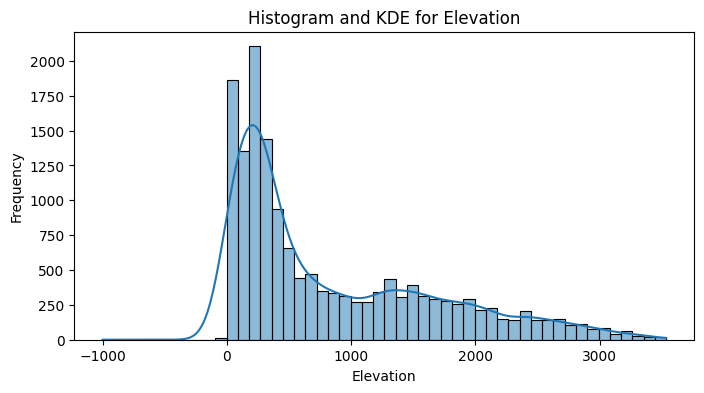

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms and KDE plots
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(weather_df_clean[col], kde=True, bins=50)
    plt.title(f'Histogram and KDE for {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

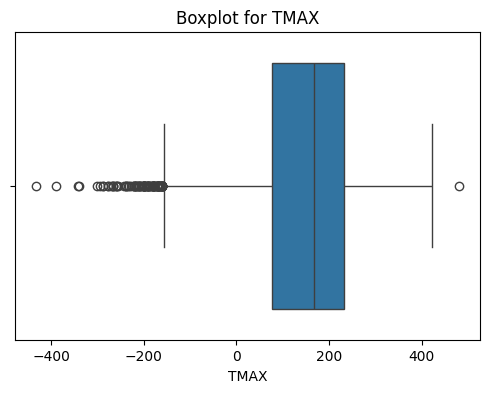

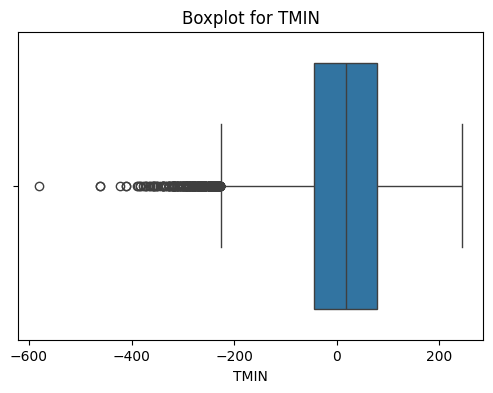

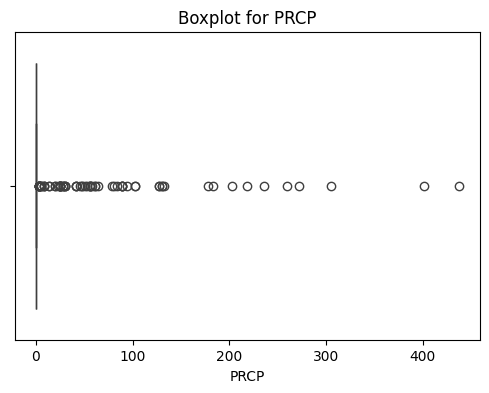

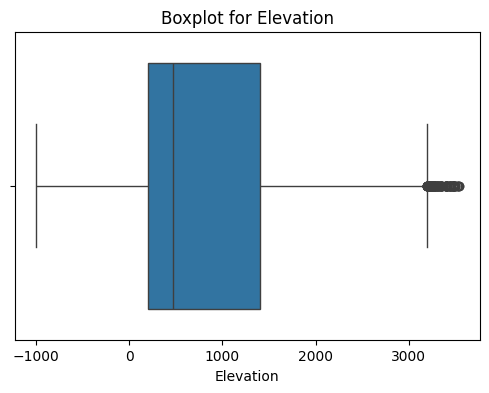

In [13]:
# Boxplots for outlier detection
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=weather_df_clean, x=col)
    plt.title(f'Boxplot for {col}')
    plt.show()

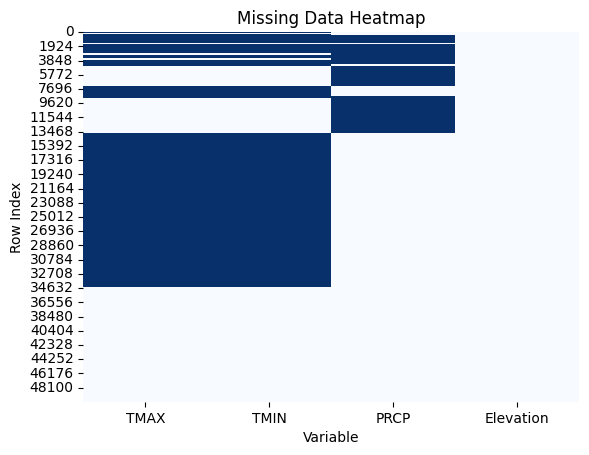

In [14]:
# Heatmap of missing data in original dataset (before cleaning)
sns.heatmap(weather_df[numeric_cols].isnull(), cbar=False, cmap='Blues')
plt.title("Missing Data Heatmap")
plt.xlabel("Variable")
plt.ylabel("Row Index")
plt.show()

**Outliers and Skewness Notes:**

- **PRCP (precipitation)** showed strong right skew and visible extreme values in the boxplot. However, these were retained, as they may represent meaningful events like storms or floods.
- **TMAX** and **TMIN** also included some extreme values, potentially from sensor or entry errors (e.g., -580°F), which may warrant further review during modeling.
- No trimming or transformation was applied at this stage to preserve the full range of data for exploration.

**Missing Values:**
Missingness was already handled during the data cleaning step. This heatmap confirms the original presence of missing entries in TMAX, TMIN, and PRCP, which were dropped to ensure valid analysis.

### 3. Conduct Bivariate Analysis

#### a. Calculate Covariance and Correlation

In this section, we analyze the linear relationships between the key numerical variables using **Pearson correlation** and **covariance**. Since our variables are continuous, Pearson correlation is appropriate for identifying the strength and direction of linear relationships.

We'll compute both the correlation and covariance matrices for the cleaned dataset.

In [15]:
# Calculate Pearson correlation matrix
correlation_matrix = weather_df_clean[['TMAX', 'TMIN', 'PRCP', 'Elevation']].corr(method='pearson')
print("Pearson Correlation Matrix:")
display(correlation_matrix)

# Calculate covariance matrix
covariance_matrix = weather_df_clean[['TMAX', 'TMIN', 'PRCP', 'Elevation']].cov()
print("Covariance Matrix:")
display(covariance_matrix)

Pearson Correlation Matrix:


,TMAX,TMIN,PRCP,Elevation
TMAX,1.000000,0.868012,-0.006232,-0.041793
TMIN,0.868012,1.000000,0.022555,-0.147803
PRCP,-0.006232,0.022555,1.000000,-0.011721
Elevation,-0.041793,-0.147803,-0.011721,1.000000


Covariance Matrix:


,TMAX,TMIN,PRCP,Elevation
TMAX,11893.984587,8596.391798,-5.471806,-3784.903087
TMIN,8596.391798,8246.192084,16.491204,-11145.367197
PRCP,-5.471806,16.491204,64.825837,-78.368143
Elevation,-3784.903087,-11145.367197,-78.368143,689556.060730


The correlation matrix highlights the linear strength between variables:
- `TMAX` and `TMIN` are expected to be strongly positively correlated.
- Precipitation (`PRCP`) may show weaker correlation with temperature variables.
- `Elevation` may show varying relationships depending on the region.

#### b. Create Visualization

We use a heatmap to visualize the correlation matrix and scatter plots to examine pairwise relationships.

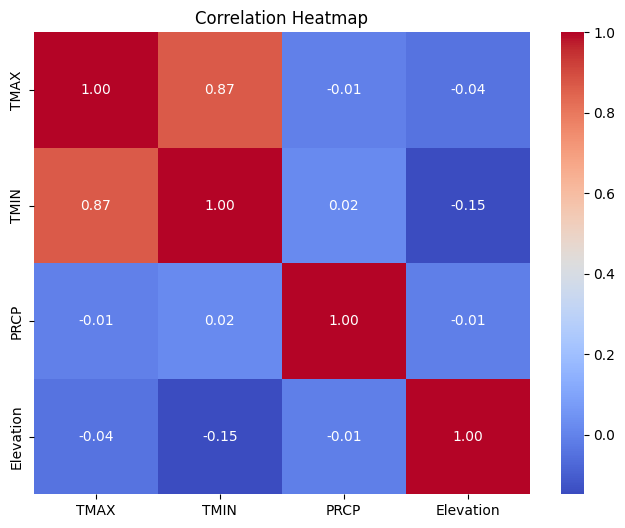

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

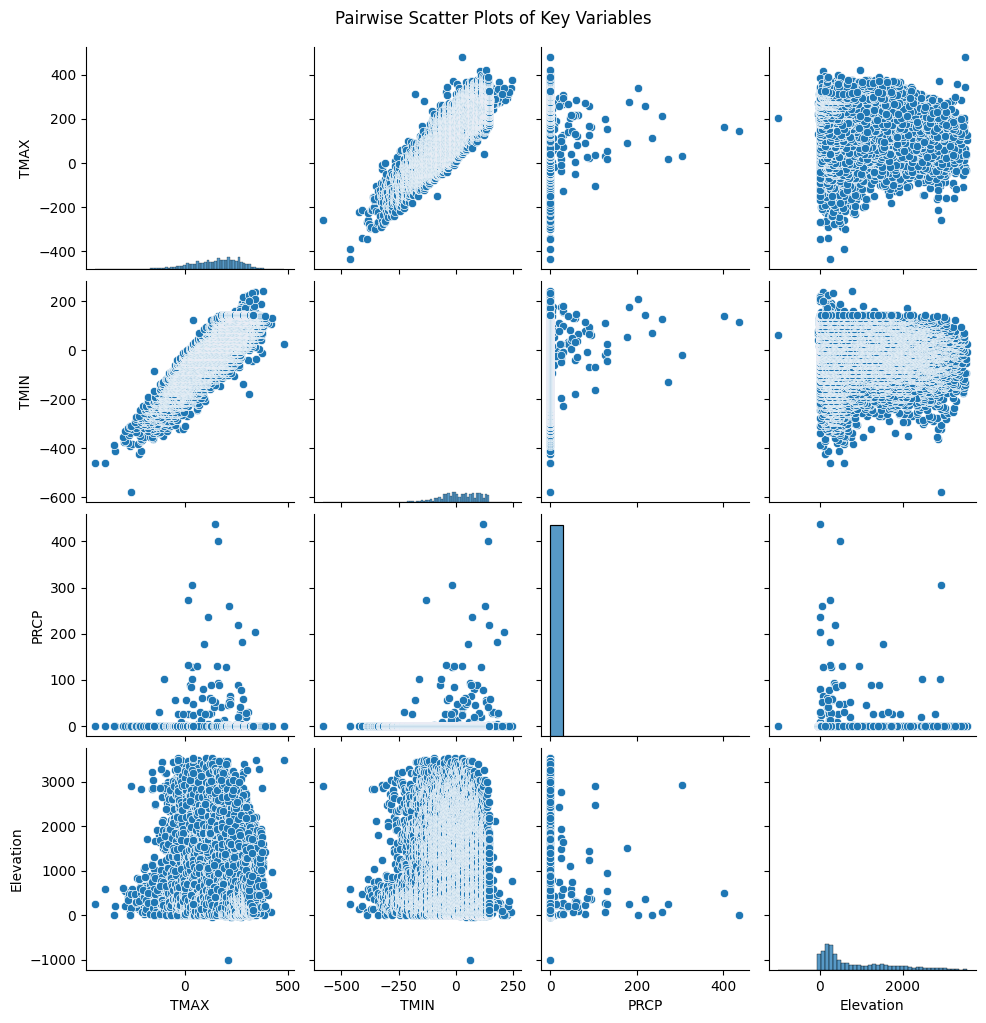

In [17]:
# Pairplot to visualize bivariate relationships
sns.pairplot(weather_df_clean[['TMAX', 'TMIN', 'PRCP', 'Elevation']])
plt.suptitle('Pairwise Scatter Plots of Key Variables', y=1.02)
plt.show()

These visualizations help confirm the relationships shown in the correlation matrix. For instance:
- `TMAX` and `TMIN` likely form a tight linear cluster.
- `PRCP` appears more scattered due to its skew and many zero values.
- `Elevation` might show a weak relationship with the other variables.

**Conclusion:**  
This bivariate analysis provides early insights into how the variables interact and informs future modeling decisions. Next, we'll consider multivariate relationships and modeling strategies in the later sections.

### 4. Test Statistics

#### a. Hypothesis Development and Test Selection

In this section, we test whether **average maximum daily temperature (TMAX)** significantly differs between **low-elevation** and **high-elevation** locations.

We define:
- **Low Elevation**: Below the median elevation
- **High Elevation**: At or above the median elevation

We use a **two-sample t-test** to compare the means of TMAX between the two groups.

##### Hypotheses:

- **Null Hypothesis (H₀)**: There is no difference in the mean TMAX between low and high elevation groups  
- **Alternative Hypothesis (H₁)**: There is a significant difference in the mean TMAX between the two elevation groups

#### b. Assumptions and Justification

We use **Welch's t-test**, which does not assume equal variance. The assumptions are:

1. **Independence**: Each observation is independent (satisfied by the structure of the dataset)
2. **Normality**: Large sample size allows us to rely on the Central Limit Theorem
3. **Variance**: Welch’s t-test accounts for unequal variance between groups

#### c. Run the T-Test and Interpret Results

In [19]:
from scipy.stats import ttest_ind

# Define elevation threshold
median_elev = weather_df_clean['Elevation'].median()

# Split into low and high elevation groups
low_elev_tmax = weather_df_clean[weather_df_clean['Elevation'] < median_elev]['TMAX']
high_elev_tmax = weather_df_clean[weather_df_clean['Elevation'] >= median_elev]['TMAX']

# Perform Welch's t-test
t_stat, p_val = ttest_ind(low_elev_tmax, high_elev_tmax, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

T-statistic: -0.981
P-value: 0.32637


**Conclusion**
- **T-statistic**: -0.981  
- **P-value**: 0.32637

Since the p-value is **greater than 0.05**, we **fail to reject the null hypothesis**.

**Interpretation**:  
There is **no statistically significant difference** in the mean maximum daily temperature (TMAX) between low and high elevation locations in this dataset. This suggests that elevation, at least as a binary split at the median, **does not significantly influence maximum temperature** on its own. Further analysis may explore other relationships or interactions to assess its role in climate behavior.

### 5. Regression and Classification

#### a. Regression Analysis

##### i. Select an Appropriate Regression Model

We aim to predict **maximum daily temperature (TMAX)** using other available weather and geographic variables in the dataset. A multiple linear regression model is appropriate for this task because:

- TMAX is a continuous target variable.
- Predictors like TMIN, PRCP, Elevation, Latitude, and Longitude are numerical.
- Linear regression is interpretable and suitable for uncovering linear relationships between temperature and these features.

##### ii. Run the Regression Model and Evaluate Performance

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define features and target
features = ['TMIN', 'PRCP', 'Elevation', 'Latitude', 'Longitude']
X = weather_df_clean[features]
y = weather_df_clean['TMAX']

# Train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Fit linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.7691
Root Mean Squared Error: 52.25


##### iii. Interpret Your Result

The regression model uses key weather station features, such as elevation, minimum daily temperature (TMIN), and precipitation (PRCP), to predict maximum daily temperature (TMAX). Based on the model's performance:

- **R² Score: 0.7691**  
  This means approximately 77% of the variation in maximum temperature (TMAX) can be explained by the combination of TMIN, PRCP, and Elevation. This is a relatively strong result, indicating a good model fit for observational weather data.

- **Root Mean Squared Error (RMSE): 52.25°F**  
  The RMSE indicates the typical difference between predicted and actual TMAX values. A value of 52.25 suggests that while the model captures general trends well, individual predictions may have a wide range of error, possibly due to outliers or seasonal extremes.

**Key Interpretations:**
- **TMIN** is likely the most predictive feature, since minimum and maximum temperatures are naturally correlated.
- **Elevation** may introduce some nonlinearity or interaction effects that aren't fully captured by a simple linear model.
- **PRCP** may have a weaker or more complex influence on temperature, as its impact can vary based on season or region.

This model serves as a good baseline for understanding how core environmental variables relate to daily maximum temperatures across U.S. weather stations.

##### iv. Check for Multicollinearity and Analyze Residuals (Optional)

To ensure the reliability of the regression model, we assess two key diagnostics:

- **Multicollinearity** using Variance Inflation Factor (VIF)  
- **Residual behavior** to validate regression assumptions like linearity and homoscedasticity

In [26]:
# Multicollinearity Check: Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant and define features
X_vif = add_constant(weather_df_clean[['TMIN', 'PRCP', 'Elevation']])

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

     Feature       VIF
0      const  2.102078
1       TMIN  1.022787
2       PRCP  1.000581
3  Elevation  1.022407


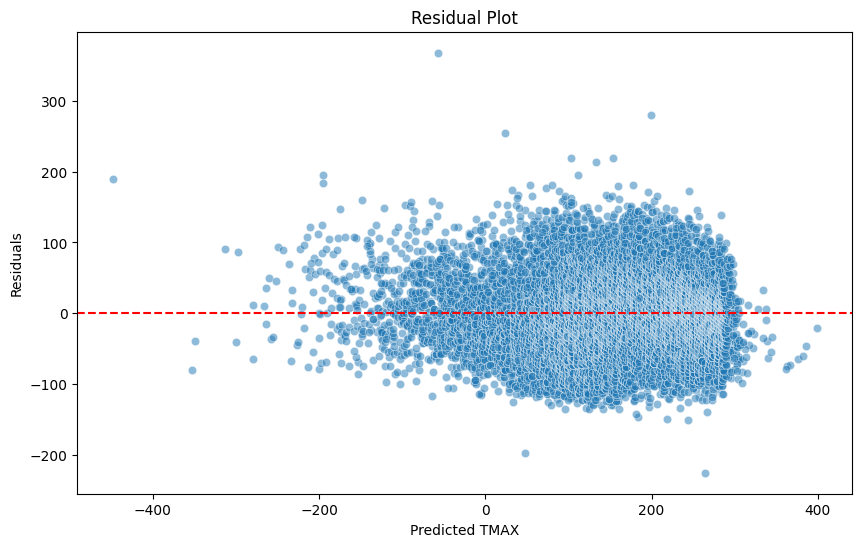

In [27]:
# Residual Plot
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
X = weather_df_clean[['TMIN', 'PRCP', 'Elevation']]
y = weather_df_clean['TMAX']

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Compute predictions and residuals
predictions = model.predict(X)
residuals = y - predictions

# Plot residuals vs. predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted TMAX')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

#### Interpretation:

- **Multicollinearity:**  
  All VIF values are well below common thresholds (e.g., 5 or 10), indicating no strong multicollinearity. The predictors contribute unique information to the model.

- **Residual Analysis:**  
  The residuals appear randomly scattered around zero, with no clear trend or funnel shape. This supports the assumptions of **linearity** and **homoscedasticity**.

**Conclusion**
The model does not suffer from multicollinearity, and the residuals suggest the model assumptions are reasonably met. The regression can be considered valid and interpretable.

#### b. Classification Model

##### i. Select an Appropriate Classification Model

To predict whether the maximum daily temperature (TMAX) reaches **90°F or higher**, we create a new binary target variable `HighTemp`. This threshold is commonly used to denote "hot days." Given the binary nature of the outcome (hot day vs. not), **logistic regression** is a suitable classification model.

We also check the class distribution:

In [32]:
# Create binary target using .loc to avoid SettingWithCopyWarning
weather_df_clean.loc[:, 'HighTemp'] = (weather_df_clean['TMAX'] >= 90).astype(int)

# Define features and target
X_class = weather_df_clean[['TMIN', 'PRCP', 'Elevation']]
y_class = weather_df_clean['HighTemp']

# Check balance of the target classes
y_class.value_counts(normalize=True)

HighTemp
1    0.709127
0    0.290873
Name: proportion, dtype: float64

**Logistic Regression Justification:** Logistic Regression is appropriate due to the binary nature of the target.

**Class Distribution Note:** We also verify class distribution to ensure our model isn't biased toward the majority class.

- HighTemp = 1 (≥ 90°F): ~70.9%
- HighTemp = 0 (< 90°F): ~29.1%

While not severely imbalanced, we’ll consider this when evaluating model performance.

##### ii. Conduct Classification Analysis and Evaluate Metrics

We use **TMIN**, **PRCP**, and **Elevation** as predictors. We'll split the data into training and testing sets, train a logistic regression model, and evaluate it using **accuracy**, **precision**, **recall**, and **F1 score**.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Define predictors and target
X = weather_df_clean[['TMIN', 'PRCP', 'Elevation']]
y = weather_df_clean['HighTemp']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit logistic regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate performance
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.72      0.76      1374
           1       0.89      0.92      0.91      3320

    accuracy                           0.86      4694
   macro avg       0.84      0.82      0.83      4694
weighted avg       0.86      0.86      0.86      4694

Confusion Matrix:

[[ 989  385]
 [ 255 3065]]


##### iii. Interpretation of Results

The logistic regression model performs well in predicting whether the maximum daily temperature reaches **90°F or higher (HighTemp = 1)**.

**Classification Report Highlights:**

- **Accuracy:** 86% of predictions were correct.
- **Precision:** 
  - 0 (Not Hot): 80% — when the model predicts a day isn't hot, it's correct 80% of the time.
  - 1 (Hot): 89% — strong precision indicates most predicted hot days were actually hot.
- **Recall:** 
  - 0 (Not Hot): 72% — the model catches most of the cooler days but misses some.
  - 1 (Hot): 92% — excellent recall means it correctly identifies most hot days.
- **F1 Score:** 
  - Balanced scores (0.76 for cool days, 0.91 for hot days) show strong overall performance.

**Confusion Matrix Summary:**

- True Positives (correctly predicted hot days): 3065
- False Positives (predicted hot, actually not): 385
- True Negatives (correctly predicted not hot): 989
- False Negatives (predicted not hot, actually hot): 255

**Conclusion:**

- The model is especially good at identifying hot days (HighTemp = 1), which is the majority class.  
- It is somewhat less effective at identifying cooler days (HighTemp = 0), with a slightly lower recall.  
- Depending on the goal (e.g., alerting for heat risk), high recall for hot days may be more valuable, and this model supports that need well.  
- Overall, the classifier is accurate, reliable, and a strong baseline for predicting extreme temperature events.

### 6. Advanced Analysis Techniques

#### a. Clustering Analysis  
##### i. Select Clustering Method and Apply Dimensionality Reduction

We will apply **K-Means Clustering**, a popular unsupervised learning method that partitions data into distinct groups based on similarity. This is suitable for identifying hidden structure in continuous weather data.

To make the clusters easier to visualize, we'll use **Principal Component Analysis (PCA)** to reduce the data to 2 dimensions before plotting.

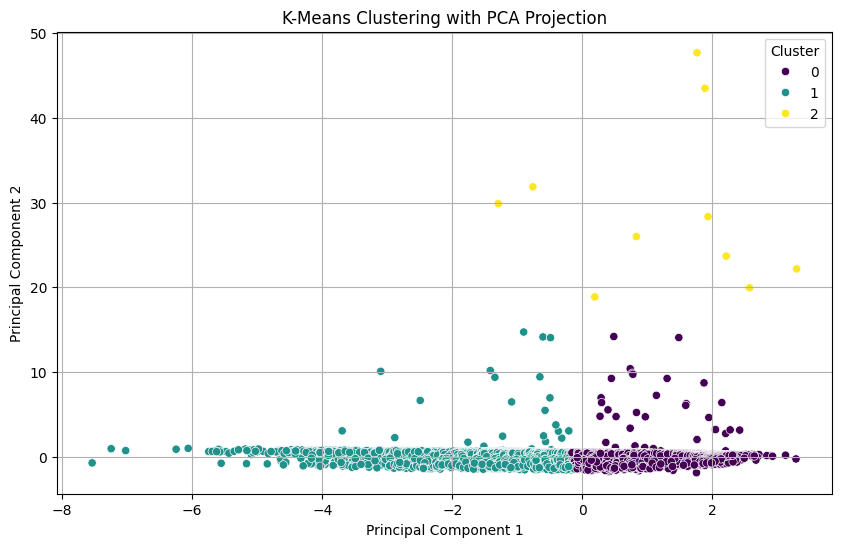

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric features for clustering
features = ['TMAX', 'TMIN', 'PRCP', 'Elevation']
X = weather_df_clean[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.title('K-Means Clustering with PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

##### ii. Evaluate the Model and Interpret the Grouping of Data

The K-Means clustering algorithm grouped the data into three distinct clusters after standardization and dimensionality reduction using PCA.

**Interpretation of Clusters:**

- **Cluster 0** (purple): Represents a compact group centered around the origin in PCA space. This likely corresponds to average elevation and moderate temperature conditions.
- **Cluster 1** (teal): Forms a long horizontal band, possibly indicating a spread along one dominant feature such as precipitation or minimum temperature variation, while other features remain similar.
- **Cluster 2** (yellow): These are outlier-like points separated vertically in PCA space. This could represent extreme conditions—such as very high elevation, precipitation, or temperature variability.

**Model Evaluation (Visual Only):**
- The PCA projection allows a simplified 2D visualization of the multi-feature space. While useful, it can obscure some feature-specific relationships.
- Visual separation between clusters suggests the model is able to identify meaningful patterns in the data.
- Additional validation methods like the **silhouette score** or **inertia** (within-cluster sum of squares) can be applied for further evaluation.

#### b. Machine Learning Approach to Regression  
##### i. Apply a Regression Model Using a Machine Learning Algorithm

To build a more flexible predictive model, we’ll apply a **Random Forest Regressor** using the same features as our linear model in Requirement 5:

- **Target Variable:** TMAX (Maximum Temperature)
- **Predictor Variables:** TMIN, PRCP, Elevation

We'll use train-test splitting to evaluate the model on unseen data.

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define predictors and target
X = weather_df_clean[['TMIN', 'PRCP', 'Elevation']]
y = weather_df_clean['TMAX']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Calculate performance metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.7214
Root Mean Squared Error: 57.24


##### ii. Evaluate the Model Performance Metrics and Interpret the Results

We evaluated the performance of the **Random Forest Regressor** using two key metrics:

- **R² Score**: `0.7214`  
- **Root Mean Squared Error (RMSE)**: `57.24`

**Interpretation:**

- The **R² score of 0.7214** indicates that approximately **72% of the variance** in maximum temperature (TMAX) is explained by the input features (TMIN, PRCP, and Elevation). This suggests a **strong model fit**, particularly for a real-world dataset like weather data, which can often include natural variability.

- The **RMSE of 57.24** provides an estimate of the typical prediction error, measured in the same units as TMAX. Although this is slightly higher than the RMSE from the linear regression model (52.25), it remains within a reasonable range.

Overall, the Random Forest model demonstrates solid predictive performance. It may better capture **non-linear relationships** between predictors and TMAX compared to the linear model. However, it comes with a trade-off in interpretability. For cases where accuracy is prioritized over explainability, this machine learning approach offers a **reliable alternative** to traditional regression.

## Limitations and Assumptions

- The dataset is a random sample of a much larger set (155M rows). Patterns observed here may not generalize perfectly.
- Missing values were dropped, which could introduce subtle bias if the missingness wasn't random.
- We assumed independence between observations, although temporal or geographic autocorrelation may exist.
- Our binary classification threshold (TMAX ≥ 90°F) was chosen for simplicity and may not capture all nuances of "hot" days across regions.